# Proyecto Integrador
## Ingeneria de Caracteristicas
Montserrat Gaytán Morales - A01332220 <br>
Alberto Eduardo De Zamacona Garza - A00590592 <br>
Ernesto Ignacio Borbón Martínez - A01701515 <br>

## Introducción

Tenco Integración de Sistemas busca optimizar su proceso de pre-venta en ingeniería y presupuestos, identificando oportunidades comerciales de alto valor y reduciendo el riesgo de proyectos con baja rentabilidad.

Este proyecto se enfoca en construir una arquitectura analítica orientada a modelos de clasificación, utilizando información estructural del proceso de preventa. En esta etapa, el objetivo principal es desarrollar ingeniería de características que permita representar variables técnicas, comerciales y financieras relevantes para futuros modelos predictivos.

### Librerias

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import random

In [ ]:
# Ignorar los warnings
warnings.filterwarnings('ignore')

# Agregar el seed para reproducibilidad
random.seed(42)

### Base de datos

In [ ]:
# Descargar la base de datos
df = pd.read_csv('construction_estimates_original.csv')

In [ ]:
# 5 primeros registros
df.head(5)

,Material_Cost,Labor_Cost,Profit_Rate,Discount_or_Markup,Policy_Reason,Total_Estimate
0,43985,12836,10,1095,Market conditions require competitive pricing ...,63598.10
1,45504,17873,15,-6426,Market conditions require competitive pricing ...,66457.55
2,33656,8401,25,9862,"The client is a repeat customer, deserving a l...",62433.25
3,36509,8523,20,8096,"The client is a repeat customer, deserving a l...",62134.40
4,37372,14123,30,-9598,Strategic importance of this client justifies ...,57345.50


In [ ]:
# Variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Material_Cost       1000 non-null   int64  
 1   Labor_Cost          1000 non-null   int64  
 2   Profit_Rate         1000 non-null   int64  
 3   Discount_or_Markup  1000 non-null   int64  
 4   Policy_Reason       1000 non-null   object 
 5   Total_Estimate      1000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


### Cambios de nombre de las variables
Renombrar los nombres de las variables de inglés a español

In [ ]:
# Cambio de nombre a las variables
df.rename(
    columns={
        'Profit_Rate':'Utilidad_Objetivo_porcentaje',
        'Discount_or_Markup':'Prima_Cliente'}
    , inplace=True)

### Generación de caractetristicas definidas en el documento
Basándonos en el estudio realizado sobre las variables disponibles y en el entendimiento del proceso de negocio, se propone la creación de nuevas variables derivadas que permitan representar de mejor manera las dinámicas comerciales, operativas y financieras involucradas en el proceso de preventa.

In [ ]:
# Costo Directo Estimado
df['Costo_Directo_Estimado'] = df['Material_Cost'] + df['Labor_Cost']
# Utilidad Objetivo
df['Utilidad_Objetivo'] = df['Costo_Directo_Estimado'] * df['Utilidad_Objetivo_porcentaje']/100
# Factor Indirecto Comercial
df['Factor_Indirecto_Comercial'] = df['Utilidad_Objetivo'] + df['Prima_Cliente'] # + df['Costo_Administrativo_Estimado'] #(No existe esta columna)
# Estrategia Precio
df['Estrategia_Precio'] = df['Costo_Directo_Estimado'] +  df['Factor_Indirecto_Comercial']
# Resultado Comercial
df['Resultado_Comercial'] = 'Aceptado'

Creación de registros con resultado comercial negativo.
Para la creación de estos resgistros se toman todos los registros cuya Prima de Cliente es menor a 0, lo que significa que la empresa tuvo que dar un descuento para poder ganar el proyecto.

In [ ]:
# Creación de registros con resultado comerical negativo
df_falledias = df[df['Prima_Cliente']<0]
df_falledias['Utilidad_Objetivo'] = abs(df_falledias['Prima_Cliente'])+df_falledias['Utilidad_Objetivo']
df_falledias['Prima_Cliente'] = 0
df_falledias['Resultado_Comercial'] = 'Rechazado'

Se concatenan las dos base de datos, los registros aceptados y los registros no aceptados

In [ ]:
df_completo = pd.concat([df,df_falledias])

Identificar los proyectos que fueron redituables

In [ ]:
df_completo.loc[df_completo['Factor_Indirecto_Comercial']>0,'Proyecto_Redituable'] = 1
df_completo.loc[df_completo['Factor_Indirecto_Comercial']<=0,'Proyecto_Redituable'] = 0

In [ ]:
# No existe el dato (cuanto dinero genero el proyecto (realmente))
#df['Desviacion_Ajustada'] = np.ones()

In [ ]:
# df_completo['Policy_Reason2'] = df_completo['Policy_Reason'].replace(
#    { 'Strategic importance of this client justifies special pricing.': 'A',
#     'This project includes additional risks, necessitating higher markup.': 'B',
#     'The client is a repeat customer, deserving a loyalty discount.': 'C',
#     'Market conditions require competitive pricing for this project.': 'D',
#     'This client is new but has potential for growth.': 'E'}
# )

Desglozar en 5 categorías la columna Policy Reason, en 5 categorías:
* Perfil_Cliente_Final:
  * 4 - Cliente con Alta Relevancia
  * 3 - Cliente con Relevancia
  * 2 - Cliente poco relevante
  * 1 - Cliente no relevante
* Relacion_Contratante_Cliente_Final:
  * 4 - Muy buena relación
  * 3 - Buena relación
  * 2 - Relación regular
  * 1 - Mala relación
* Calidad_Solicitud:
  * 4 - Alta calidad de solicitud
  * 3 - Calidad de la solicitud buena
  * 2 - Baja Calidad de solicitud
  * 1 - Muy baja calidad de solicitud
* Presion_Preventa:
  * 0 - 7 días (solicitud alta importancia)
  * 7 - 14 días (solicitud importancia normal)
  * 14 - 21 días (solicitud baja importancia)
* Complejidad_preproyecto:
  * 4 - Muy Complejo
  * 3 - Complejo
  * 2 - Poco complejo
  * 1 - No complejo

In [ ]:
condiciones = [
    (df_completo['Policy_Reason'] == 'Strategic importance of this client justifies special pricing.'),
    (df_completo['Policy_Reason'] == 'This project includes additional risks, necessitating higher markup.'),
    (df_completo['Policy_Reason'] == 'The client is a repeat customer, deserving a loyalty discount.'),
    (df_completo['Policy_Reason'] == 'Market conditions require competitive pricing for this project.'),
    (df_completo['Policy_Reason'] == 'This client is new but has potential for growth.')
]

df_completo['Perfil_Cliente_Final'] = np.select(condiciones, [4, 3, 2, 2, 3], default=np.nan)
df_completo['Relacion_Contratante_Cliente_Final'] = np.select(condiciones, [4, 4, 2, 2, 1], default=np.nan)
df_completo['Calidad_Solicitud'] = np.select(condiciones, [3, 4, 3, 1, 2], default=np.nan)
df_completo['Presion_Preventa'] = np.select(condiciones, [7, 21, 7, 7, 14], default=np.nan) # dias (menos dias mas presion, mas dias menos presion)
df_completo['Complejidad_preproyecto'] = np.select(condiciones, [4, 2, 3, 4, 3], default=np.nan)

# calificacion 1 a 4, siendo el 4 el mas importante/valioso

In [ ]:
df_completo.head(5)

,Material_Cost,Labor_Cost,Utilidad_Objetivo_porcentaje,Prima_Cliente,Policy_Reason,Total_Estimate,Costo_Directo_Estimado,Utilidad_Objetivo,Factor_Indirecto_Comercial,Estrategia_Precio,Resultado_Comercial,Proyecto_Redituable,Perfil_Cliente_Final,Relacion_Contratante_Cliente_Final,Calidad_Solicitud,Presion_Preventa,Complejidad_preproyecto
0,43985,12836,10,1095,Market conditions require competitive pricing ...,63598.10,56821,5682.10,6777.10,63598.10,Aceptado,1.0,2.0,2.0,1.0,7.0,4.0
1,45504,17873,15,-6426,Market conditions require competitive pricing ...,66457.55,63377,9506.55,3080.55,66457.55,Aceptado,1.0,2.0,2.0,1.0,7.0,4.0
2,33656,8401,25,9862,"The client is a repeat customer, deserving a l...",62433.25,42057,10514.25,20376.25,62433.25,Aceptado,1.0,2.0,2.0,3.0,7.0,3.0
3,36509,8523,20,8096,"The client is a repeat customer, deserving a l...",62134.40,45032,9006.40,17102.40,62134.40,Aceptado,1.0,2.0,2.0,3.0,7.0,3.0
4,37372,14123,30,-9598,Strategic importance of this client justifies ...,57345.50,51495,15448.50,5850.50,57345.50,Aceptado,1.0,4.0,4.0,3.0,7.0,4.0


Crear el perfil del cliente contratante en base a los quartiles de la estrategía de precio.

In [ ]:
# Perfil del cliente contratante (en base a el monto del proyecto)
df_completo['Perfil_Cliente_Contratante'] = pd.qcut(df['Estrategia_Precio'], q=4, labels=[1, 2, 3, 4])

In [ ]:
df_completo.head(1)

,Material_Cost,Labor_Cost,Utilidad_Objetivo_porcentaje,Prima_Cliente,Policy_Reason,Total_Estimate,Costo_Directo_Estimado,Utilidad_Objetivo,Factor_Indirecto_Comercial,Estrategia_Precio,Resultado_Comercial,Proyecto_Redituable,Perfil_Cliente_Final,Relacion_Contratante_Cliente_Final,Calidad_Solicitud,Presion_Preventa,Complejidad_preproyecto,Perfil_Cliente_Contratante
0,43985,12836,10,1095,Market conditions require competitive pricing ...,63598.1,56821,5682.1,6777.1,63598.1,Aceptado,1.0,2.0,2.0,1.0,7.0,4.0,3


In [ ]:
df_completo.loc[df_completo['Proyecto_Redituable']== 0,'Policy_Reason'] = 'Non winning proposal'

Creación de la variable objetivo

In [ ]:
# Variable objetivo
df_completo['Resultado_Comercial'].replace({'Aceptado':1,'Rechazado':0},inplace=True)
# df_completo['Proyecto_Redituable']# depende de la desviación ajustada

## Selección de características

### Eliminación de columnas intermedias

In [ ]:
# Eliminar columnas intermedias
df_completo.drop(columns={'Policy_Reason','Utilidad_Objetivo_porcentaje','Total_Estimate'}, inplace=True) # 'Policy_Reason2',

In [ ]:
df_completo.columns

Index(['Material_Cost', 'Labor_Cost', 'Prima_Cliente',
       'Costo_Directo_Estimado', 'Utilidad_Objetivo',
       'Factor_Indirecto_Comercial', 'Estrategia_Precio',
       'Resultado_Comercial', 'Proyecto_Redituable', 'Perfil_Cliente_Final',
       'Relacion_Contratante_Cliente_Final', 'Calidad_Solicitud',
       'Presion_Preventa', 'Complejidad_preproyecto',
       'Perfil_Cliente_Contratante'],
      dtype='object')

### Eliminar variables para evitar multicolinealidad

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_completo.drop(columns=['Resultado_Comercial']), df_completo['Resultado_Comercial'], test_size=0.3, random_state=42)

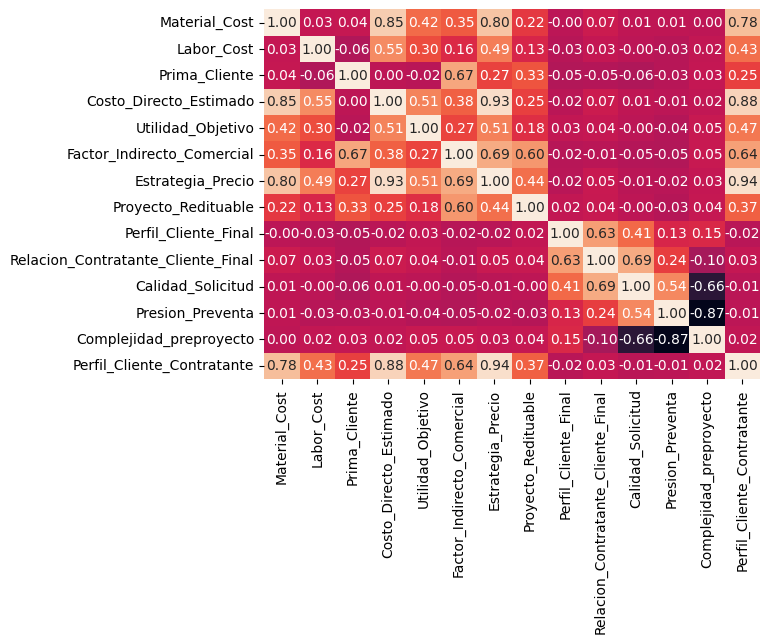

In [ ]:
plt.figzize = (25,25)
corr = X_train.corr()
sns.heatmap(corr, annot=True, cbar=False, fmt = ".2f")
plt.show()

Se eliminan, estas variables se eliminan estas variables para evitar multicolinealidad, lo que se traduce en un modelo más facil de interpretar y evita perjudicar modelos de regresión (regresión logística y LDA)

In [ ]:
# Para evitar multicolinealidad se eliminan las siguientes variables
  # Material_Cost, Labor_Cost (razon estan muy correlacionadas, y ayuaron a la creacion de otras columnas
  # Prima_Cliente (Correlacionada se elimina, compone otras variables)
  # Perfil_Cliente_Contratante
  # Estrategia_Precio
  # Proyecto_Redituable
cols_eliminar = ['Material_Cost','Labor_Cost','Prima_Cliente','Perfil_Cliente_Contratante','Estrategia_Precio','Proyecto_Redituable']

Como podemos notar, no todas las variables correlacionadas fueron eliminadas, es este el caso porque son variables que en base al conocimiento experto del negocio son útiles e importantes para la identificación de los proyectos que serán aceptados o no.

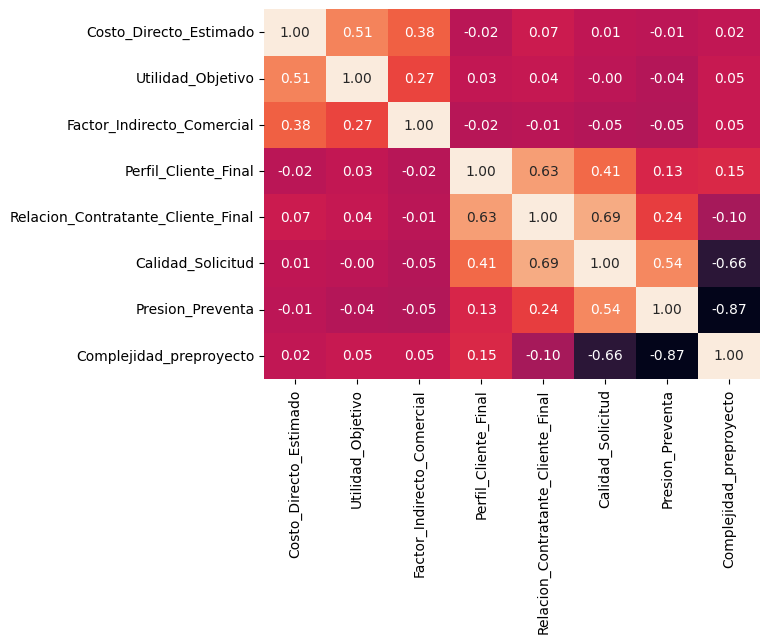

In [ ]:
plt.figzize = (20,15)
corr = X_train.drop(columns=cols_eliminar).corr()
sns.heatmap(corr, annot=True, cbar=False, fmt = ".2f")
plt.show()

## Modificación de las variables para el consumo del modelo

### Escalamiento de variables
## Estandarización de las variables
Se estandarizan las variables numéricas ['Costo_Directo_Estimado', 'Utilidad_Objetivo', 'Factor_Indirecto_Comercial', 'Resultado_Comercial'], con el objetivo de evitar la posibilidad de sesgos en el modelo debido al rango de los valores de las variables.

## Normalización de las variables
Se normalizan las variables ordinales ['Perfil_Cliente_Final', 'Relacion_Contratante_Cliente_Final', 'Calidad_Solicitud', 'Presion_Preventa', 'Complejidad_preproyecto'] esto con miras a acotar las variables entre [0,1] para no meter un sesgo al modelo en el entrenamiento.

In [ ]:
cols_est = ['Costo_Directo_Estimado','Utilidad_Objetivo','Factor_Indirecto_Comercial']
cols_norm = ['Perfil_Cliente_Final','Relacion_Contratante_Cliente_Final','Calidad_Solicitud','Presion_Preventa','Complejidad_preproyecto']

# Estandarizar las variables (en caso de necesitar un modelo distinto a un arbol de decision para no sesgar el modelo con los ingresos)
scaler = StandardScaler()
X_train_est = scaler.fit_transform(X_train[cols_est])
X_train_est = pd.DataFrame(X_train_est)
X_train_est.columns = X_train[cols_est].columns
X_test_est = pd.DataFrame(scaler.transform(X_test[cols_est]))
X_test_est.columns = X_test[cols_est].columns

# Normalizar las variables
min_max = MinMaxScaler()
X_train_norm = min_max.fit_transform(X_train[cols_norm])
X_train_norm = pd.DataFrame(X_train_norm)
X_train_norm.columns = X_train[cols_norm].columns
X_test_norm = min_max.transform(X_test[cols_norm])
X_test_norm = pd.DataFrame(X_test_norm)
X_test_norm.columns = X_test[cols_norm].columns

In [ ]:
X_train_scaled = pd.concat([X_train_est,X_train_norm],axis=1)
X_test_scaled = pd.concat([X_test_est,X_test_norm],axis=1)

In [ ]:
X_train_scaled.columns

Index(['Costo_Directo_Estimado', 'Utilidad_Objetivo',
       'Factor_Indirecto_Comercial', 'Perfil_Cliente_Final',
       'Relacion_Contratante_Cliente_Final', 'Calidad_Solicitud',
       'Presion_Preventa', 'Complejidad_preproyecto'],
      dtype='object')

In [ ]:
X_train_scaled.head(5)

,Costo_Directo_Estimado,Utilidad_Objetivo,Factor_Indirecto_Comercial,Perfil_Cliente_Final,Relacion_Contratante_Cliente_Final,Calidad_Solicitud,Presion_Preventa,Complejidad_preproyecto
0,1.041574,1.414801,1.388085,1.0,1.000000,0.666667,0.0,1.0
1,0.185063,0.300476,-0.055277,0.5,1.000000,1.000000,1.0,0.0
2,-1.115408,-1.194402,0.841286,0.0,0.333333,0.000000,0.0,1.0
3,-1.517511,-1.607319,0.190198,0.5,0.000000,0.333333,0.5,0.5
4,-0.725885,-1.042305,-0.096130,0.5,0.000000,0.333333,0.5,0.5


### Justificación de variables conservadas

La selección de variables se realizó combinando criterio experto del dominio con una lógica de reducción de dimensionalidad. El objetivo fue conservar únicamente las variables que representan señales relevantes para explicar la aceptación comercial y la rentabilidad esperada de una propuesta.

Las variables conservadas fueron:

| Variable | Justificación |
|---|---|
| Costo_Directo_Estimado | Representa la base económica del proyecto. Permite dimensionar el tamaño de la propuesta y sirve como punto de partida para calcular márgenes, indirectos y precio final. |
| Utilidad_Objetivo | Representa la rentabilidad esperada por Tenco antes de presentar la propuesta. Se conserva porque el objetivo no es solo ganar propuestas, sino identificar oportunidades que también protejan el margen. |
| Factor_Indirecto_Comercial | Integra costos administrativos, utilidad objetivo y ajustes comerciales asociados al cliente, riesgo o estrategia de precio. Es una variable central para entender cómo se construye el precio final. |
| Perfil_Cliente_Final | Representa la relevancia del cliente para quien se construye. Se conserva porque el cliente final puede influir en exigencia técnica, capacidad de pago, estándares requeridos y riesgo comercial. |
| Relacion_Contratante_Cliente_Final | Captura la fortaleza de la relación entre quien contrata y el cliente final. Esta relación puede afectar claridad de requerimientos, velocidad de decisión, negociación y riesgo de ejecución. |
| Calidad_Solicitud | Representa qué tan clara y completa es la información inicial recibida para cotizar. Una solicitud incompleta aumenta el riesgo de omisiones, errores de estimación y desviaciones posteriores. |
| Presion_Preventa | Representa el tiempo disponible para preparar la cotización. Menos tiempo implica mayor presión, menor profundidad de revisión y mayor probabilidad de error. |
| Complejidad_preproyecto | Resume la dificultad técnica y comercial esperada antes de ejecutar el proyecto. Se conserva porque la complejidad puede aumentar el riesgo de desviaciones, errores de alcance y subestimación de costos. |

Estas variables concentran las principales dimensiones del proceso de preventa:

| Dimensión | Variables asociadas |
|---|---|
| Economía del proyecto | Costo_Directo_Estimado, Utilidad_Objetivo, Factor_Indirecto_Comercial |
| Cliente y relación comercial | Perfil_Cliente_Final, Relacion_Contratante_Cliente_Final |
| Calidad de información | Calidad_Solicitud |
| Presión operativa | Presion_Preventa |
| Riesgo técnico y comercial | Complejidad_preproyecto |

La selección permite reducir variables redundantes, disminuir la complejidad del modelo, facilitar la interpretación y acelerar el entrenamiento. Además, es consistente con la literatura de estimación de costos en construcción y con estudios sobre decisiones bid/no-bid, donde se identifican como relevantes factores como costo, riesgo, rentabilidad esperada, características del cliente, presión de tiempo y complejidad del proyecto.

## Conclusión Preparación de los datos CRISP-ML
La fase de preparación de datos dentro de la metodología CRISP-ML(Q) fue fundamental para transformar la información original en un conjunto de datos adecuado para el entrenamiento de modelos de ML. Durante esta etapa se realizaron actividades como corrección de tipos de datos, identificación de valores faltantes, análisis de distribuciones, tratamiento de inconsistencias y evaluación de transformaciones sobre variables con asimetría.

A partir del análisis exploratorio se identificaron patrones de ausencia conjunta entre variables, lo que sugiere que algunos faltantes responden a condiciones operativas del proceso y no únicamente a errores aleatorios de captura. Asimismo, se aplicaron técnicas de codificación, escalamiento y selección de características para reducir redundancia, disminuir complejidad y mejorar la capacidad de generalización del modelo.

La preparación de variables no se realizó únicamente desde un enfoque estadístico, sino también incorporando conocimiento experto del dominio. Lo que permitió definir y conservar variables relevantes para el negocio incluso en casos de multicolinealidad, priorizando interpretabilidad y utilidad operativa además del desempeño predictivo.

Finalmente, esta etapa reflejó el carácter iterativo de CRISP-ML(Q), ya que la preparación de datos puede ajustarse continuamente conforme se evalúan modelos y se identifican nuevas oportunidades de mejora en la calidad y representatividad de la información.

## Referencias

*  Aldossari, K. M. (2024). Exploring bid/no-bid decision factors of construction contractors for building and infrastructure projects. Buildings, 14(10), Article 3114. https://doi.org/10.3390/buildings14103114

*  Hashemi, S. T., Ebadati, O. M., & Kaur, H. (2020). Cost estimation and prediction in construction projects: A systematic review on machine learning techniques. SN Applied Sciences, 2, Article 1703. https://doi.org/10.1007/s42452-020-03497-1

*  Sasaki, T. (2024). Construction Estimation Data [Data set]. Kaggle. https://www.kaggle.com/datasets/sasakitetsuya/construction-estimation-data

*  scikit-learn developers. (n.d.). Feature selection. Scikit-learn. Retrieved May 17, 2026, from https://scikit-learn.org/stable/modules/feature_selection.html